In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df_train = pd.read_csv('trainset (1).csv')
df_test = pd.read_csv('testset.csv')

train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [3]:
scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [4]:
def create_sequences(data, seq_length):
    x = []
    y = []

    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(x), np.array(y)

seq_length = 60

x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)

In [5]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [6]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [8]:
model = RNNModel()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
epochs = 20
train_losses = []

model.train()

for epoch in range(epochs):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}')

Epoch 1/20, Loss: 0.067080
Epoch 2/20, Loss: 0.010684
Epoch 3/20, Loss: 0.001458
Epoch 4/20, Loss: 0.000587
Epoch 5/20, Loss: 0.000441
Epoch 6/20, Loss: 0.000423
Epoch 7/20, Loss: 0.000402
Epoch 8/20, Loss: 0.000390
Epoch 9/20, Loss: 0.000378
Epoch 10/20, Loss: 0.000375
Epoch 11/20, Loss: 0.000426
Epoch 12/20, Loss: 0.000364
Epoch 13/20, Loss: 0.000368
Epoch 14/20, Loss: 0.000340
Epoch 15/20, Loss: 0.000330
Epoch 16/20, Loss: 0.000360
Epoch 17/20, Loss: 0.000366
Epoch 18/20, Loss: 0.000331
Epoch 19/20, Loss: 0.000340
Epoch 20/20, Loss: 0.000317


Name: DAKSHA C
Register Number: 212224230048


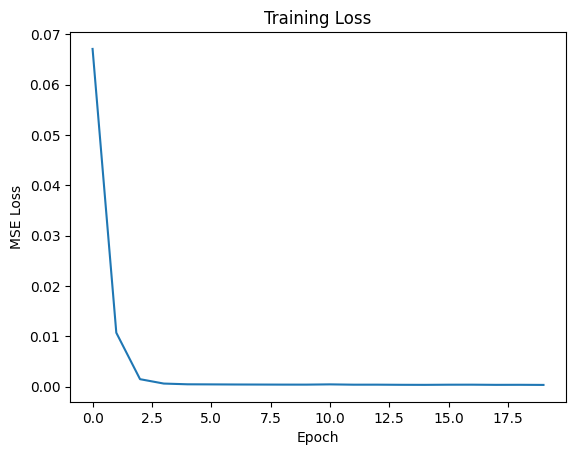

In [16]:
print('Name: DAKSHA C')
print('Register Number: 212224230048')
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.show()

In [11]:
model.eval()

with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

In [12]:
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

Name: DAKSHA C
Register Number: 212224230048


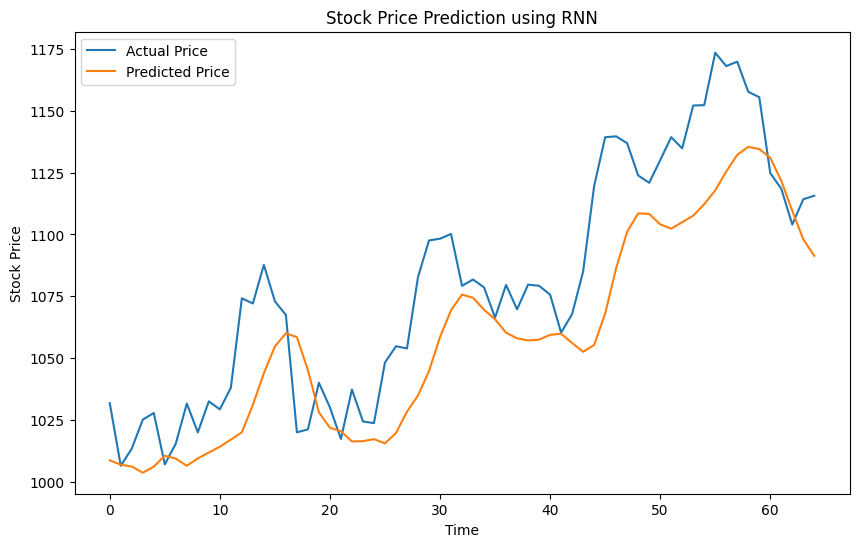

Predicted Price: 1091.3452
Actual Price: 1115.65


In [15]:
print('Name: DAKSHA C')
print('Register Number: 212224230048')
plt.figure(figsize=(10,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()

print("Predicted Price:", predicted_prices[-1][0])
print("Actual Price:", actual_prices[-1][0])